In [1]:
from animal_results import AnimalResults
from utilities import get_grid_figure, get_p_value, draw_l2_histogram, draw_p_value_comparison_histogram, \
    draw_p_value_histogram

In [2]:
animal_results = AnimalResults.from_csv(path="data/fepsp_ca1.csv", excluded_group_ids=["CTR"])
grouped_by_animal = animal_results.group_by_animal()
grouped_by_group = grouped_by_animal.group_by_group()
randomized = grouped_by_animal.randomize_groups()
randomized_grouped_by_group = randomized.group_by_group()

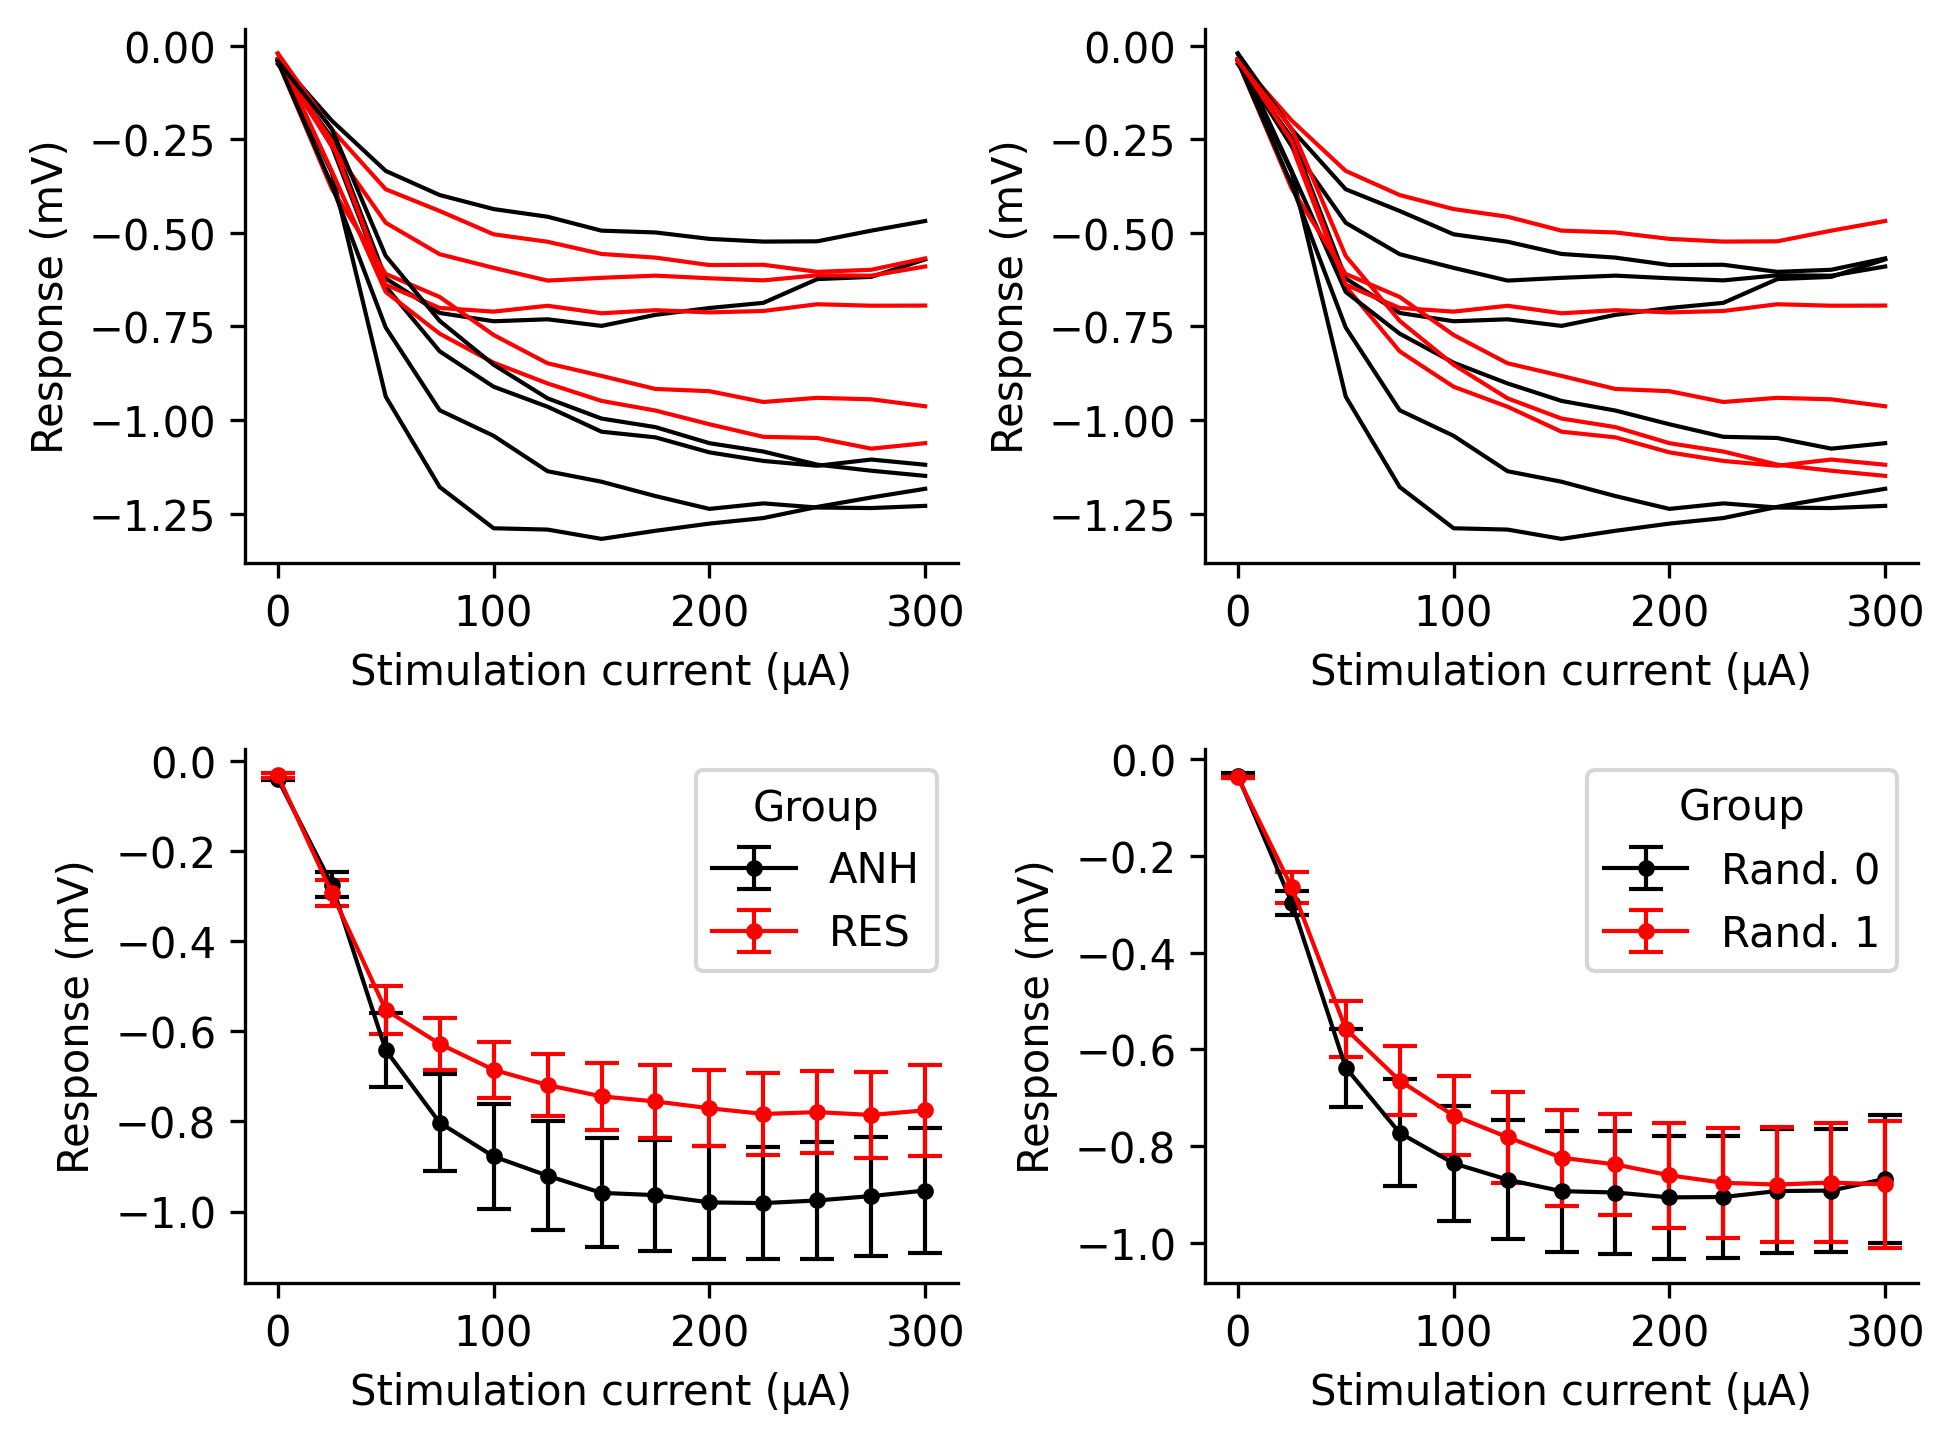

In [3]:
_, axes = get_grid_figure(row_count=2, column_count=2)
grouped_by_animal.plot(axes[0, 0])
randomized.plot(axes[0, 1])
grouped_by_group.plot(axes[1, 0])
randomized_grouped_by_group.plot(axes[1, 1])

In [4]:
l2 = grouped_by_group.get_l2()
randomization_counts = [250, 1000, 5000]
p_values = []
for rc in randomization_counts:
    series = []
    for _ in range(100):
        randomized_group_l2s = [grouped_by_animal.randomize_groups().group_by_group().get_l2() for _ in range(rc)]
        series.append(get_p_value(randomized_group_l2s, l2))
    p_values.append(series)
randomized_group_l2s = [grouped_by_animal.randomize_groups().group_by_group().get_l2() for _ in range(1000)]
l2, get_p_value(randomized_group_l2s, l2)

(9.29907449064014, 0.23)

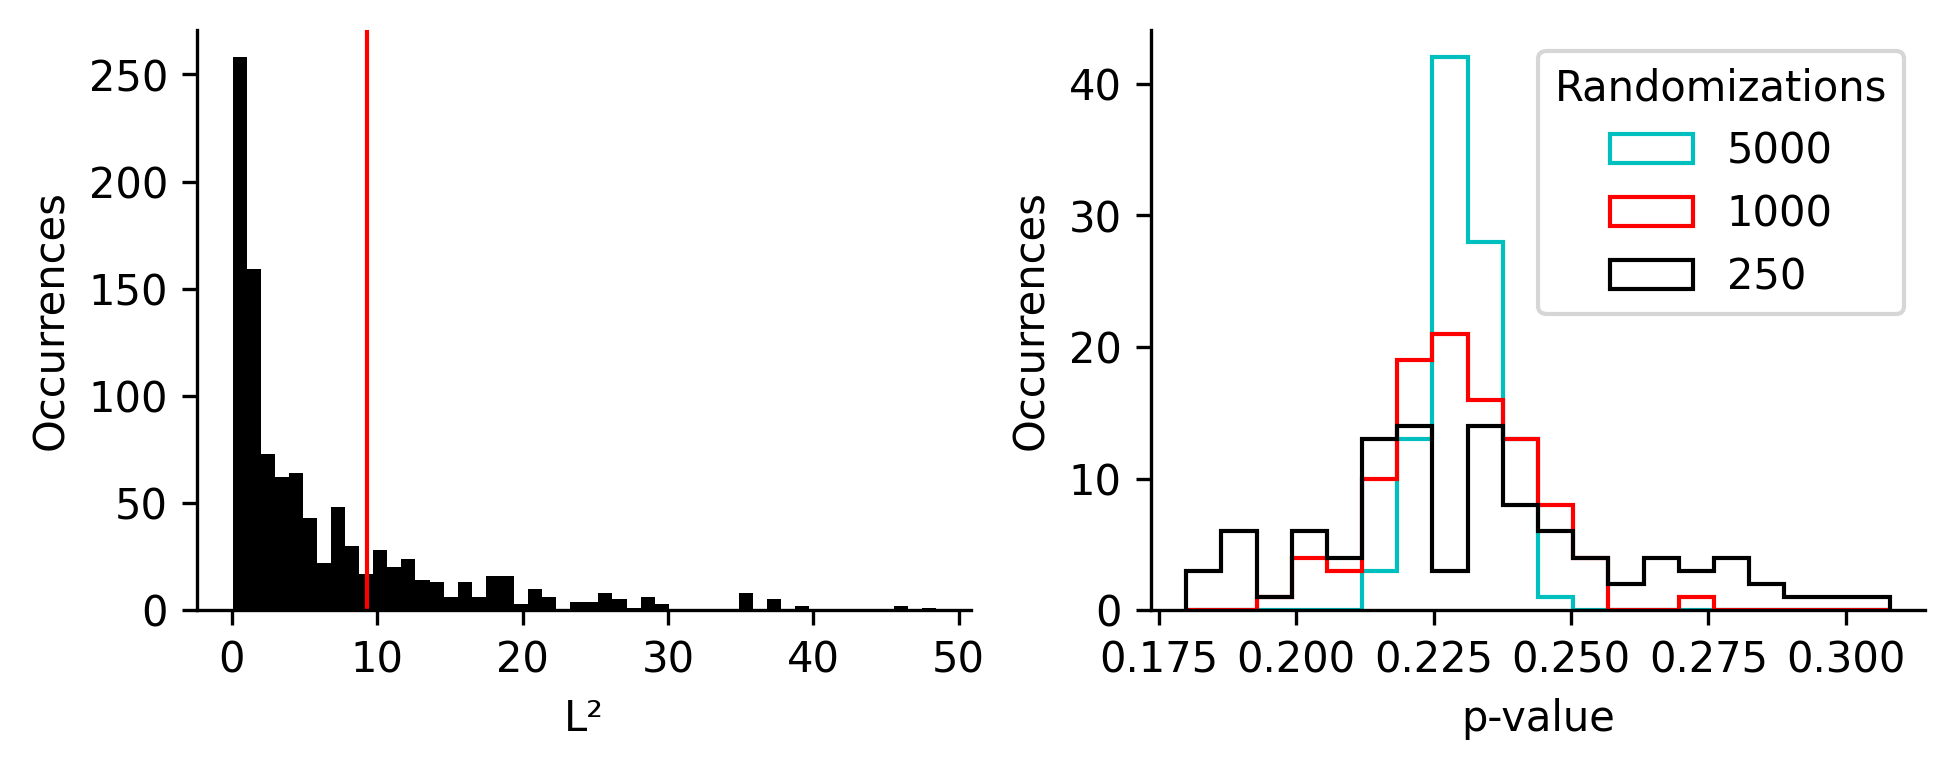

In [5]:
_, axes = get_grid_figure(column_count=2)
draw_l2_histogram(axes=axes[0], results=randomized_group_l2s, threshold=l2, bin_count=50)
draw_p_value_comparison_histogram(
    axes=axes[1],
    results=p_values,
    randomization_counts=randomization_counts,
    bin_count=20,
)

In [6]:
animal_results = AnimalResults.from_csv(path="LTP5_slope_diffsubjects.csv")
without_differences = animal_results.to_fake()
with_differences = animal_results.to_fake(keep_differences=True)

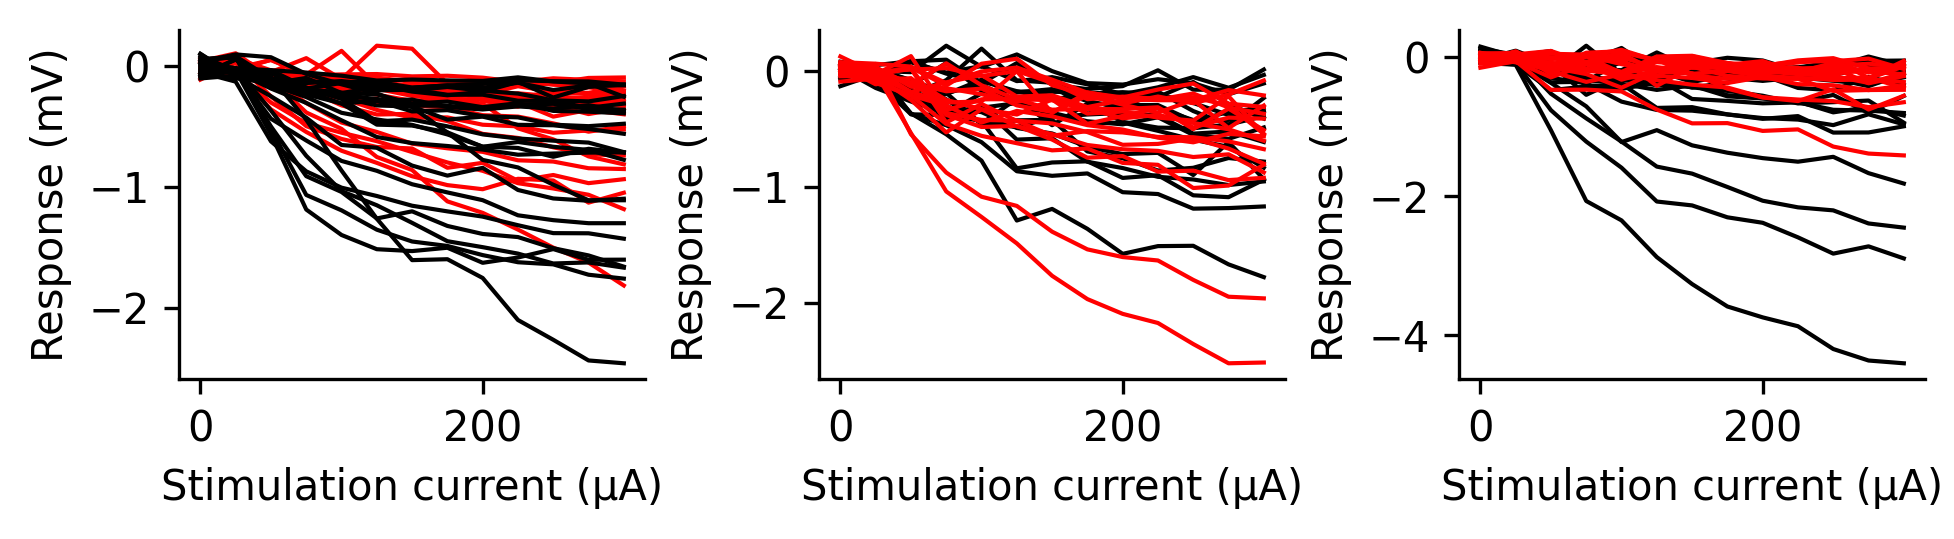

In [7]:
_, axes = get_grid_figure(column_count=3)
animal_results.plot(axes[0])
without_differences.plot(axes[1])
with_differences.plot(axes[2])

In [8]:
p_values_without_differences = []
for _ in range(1000):
    fake = animal_results.to_fake()
    grouped_by_animal = fake.group_by_animal()
    grouped_by_group = grouped_by_animal.group_by_group()
    l2 = grouped_by_group.get_l2()
    randomized_group_l2s = [grouped_by_animal.randomize_groups().group_by_group().get_l2() for _ in range(2000)]
    p_values_without_differences.append(get_p_value(randomized_group_l2s, l2))
p_values_with_differences = []
for _ in range(1000):
    fake = animal_results.to_fake(keep_differences=True)
    grouped_by_animal = fake.group_by_animal()
    grouped_by_group = grouped_by_animal.group_by_group()
    l2 = grouped_by_group.get_l2()
    randomized_group_l2s = [grouped_by_animal.randomize_groups().group_by_group().get_l2() for _ in range(2000)]
    p_values_with_differences.append(get_p_value(randomized_group_l2s, l2))

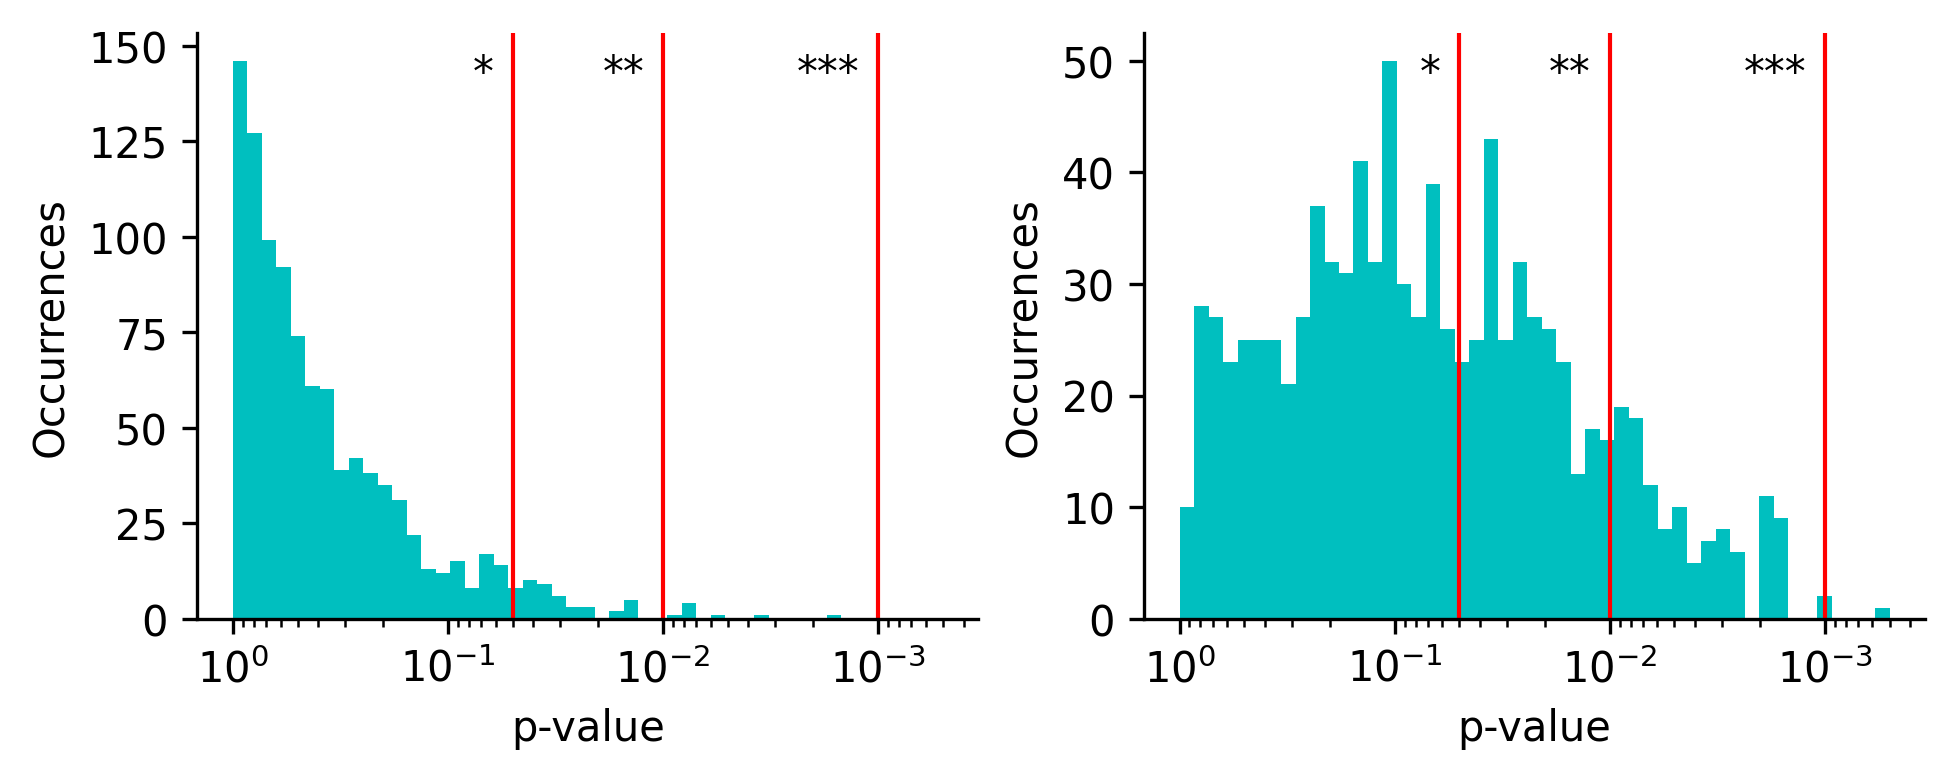

In [9]:
figure, axes = get_grid_figure(column_count=2)
draw_p_value_histogram(
    axes=axes[0],
    results=p_values_without_differences,
    bin_count=50,
    dpi_scale_transform=figure.dpi_scale_trans,
)
draw_p_value_histogram(
    axes=axes[1],
    results=p_values_with_differences,
    bin_count=50,
    dpi_scale_transform=figure.dpi_scale_trans,
)